# Grant Witness

## 1. Setup

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

pd.set_option('display.max_colwidth', 120)
pd.set_option('display.max_rows', 60)


In [ ]:
df = pd.read_parquet('00_data/eval_predictions.parquet')

VARIANTS = [
    ('text_only', 'y_pred_text_only'),
    ('no_state', y_pred_no_state'),
    ('full', 'y_pred_full'),
    ('emb', 'y_pred_emb'),
]

for name, pred_col in VARIANTS:
    err_col = f'error_{name}'
    df[err_col] = df.apply(
        lambda r, p=pred_col: (
            'TP' if r.y_true == 1 and r[p] == 1 else
            'TN' if r.y_true == 0 and r[p] == 0 else
            'FP' if r.y_true == 0 and r[p] == 1 else 'FN'
        ), axis=1
    )

df['diff_meta'] = df['y_prob_no_state']  - df['y_prob_text_only']
df['diff_state'] = df['y_prob_full']       - df['y_prob_no_state']
df['diff_tfidf_emb'] = df['y_prob_text_only']  - df['y_prob_emb']

print(f'Test set: {len(df):,} rows | positive rate: {df.y_true.mean():.3f}')
print(df.groupby('agency')['y_true'].agg(['count', 'sum', 'mean'])
        .rename(columns={'mean': 'pos_rate'}).round(3))


Test set: 1,422 rows | positive rate: 0.174
        count  sum  pos_rate
agency                      
NIH       562   26     0.046
NSF       344  221     0.642
SAMHSA    516    1     0.002


## 2. Classification overview

In [ ]:
for name, pred_col in VARIANTS:
    print(f'\n=== {name} ===')
    print(classification_report(df['y_true'], df[pred_col],
                                 target_names=['not adverse', 'adverse']))



=== text_only ===
              precision    recall  f1-score   support

 not adverse       0.98      0.95      0.96      1174
     adverse       0.80      0.89      0.84       248

    accuracy                           0.94      1422
   macro avg       0.89      0.92      0.90      1422
weighted avg       0.95      0.94      0.94      1422


=== no_state ===
              precision    recall  f1-score   support

 not adverse       0.98      0.96      0.97      1174
     adverse       0.81      0.89      0.85       248

    accuracy                           0.94      1422
   macro avg       0.89      0.92      0.91      1422
weighted avg       0.95      0.94      0.95      1422


=== full ===
              precision    recall  f1-score   support

 not adverse       0.99      0.97      0.98      1174
     adverse       0.88      0.96      0.92       248

    accuracy                           0.97      1422
   macro avg       0.93      0.97      0.95      1422
weighted avg       0.97

In [ ]:
counts = pd.DataFrame({
    name: df[f'error_{name}'].value_counts()
    for name, _ in VARIANTS
}).fillna(0).astype(int)
print(counts)


    text_only  no_state  full   emb
TN       1119      1123  1141  1118
TP        221       220   238   205
FP         55        51    33    56
FN         27        28    10    43


## 3. Agency-level error breakdown

In [ ]:
rows = []
for agency, grp in df.groupby('agency'):
    for name, pred_col in VARIANTS:
        ec = grp[f'error_{name}'].value_counts().to_dict()
        rows.append({
            'agency': agency, 'variant': name,
            'n': len(grp), 'pos_rate': round(grp.y_true.mean(), 3),
            'TP': ec.get('TP', 0), 'TN': ec.get('TN', 0),
            'FP': ec.get('FP', 0), 'FN': ec.get('FN', 0),
        })
df_agency = pd.DataFrame(rows).set_index(['agency', 'variant'])
df_agency


n  pos_rate   TP   TN  FP  FN
agency variant                                   
NIH    text_only  562     0.046    1  532   4  25
       no_state   562     0.046    2  528   8  24
       full       562     0.046   25  535   1   1
       emb        562     0.046    6  508  28  20
NSF    text_only  344     0.642  220   72  51   1
       no_state   344     0.642  218   80  43   3
       full       344     0.642  213  105  18   8
       emb        344     0.642  199   99  24  22
SAMHSA text_only  516     0.002    0  515   0   1
       no_state   516     0.002    0  515   0   1
       full       516     0.002    0  501  14   1
       emb        516     0.002    0  511   4   1

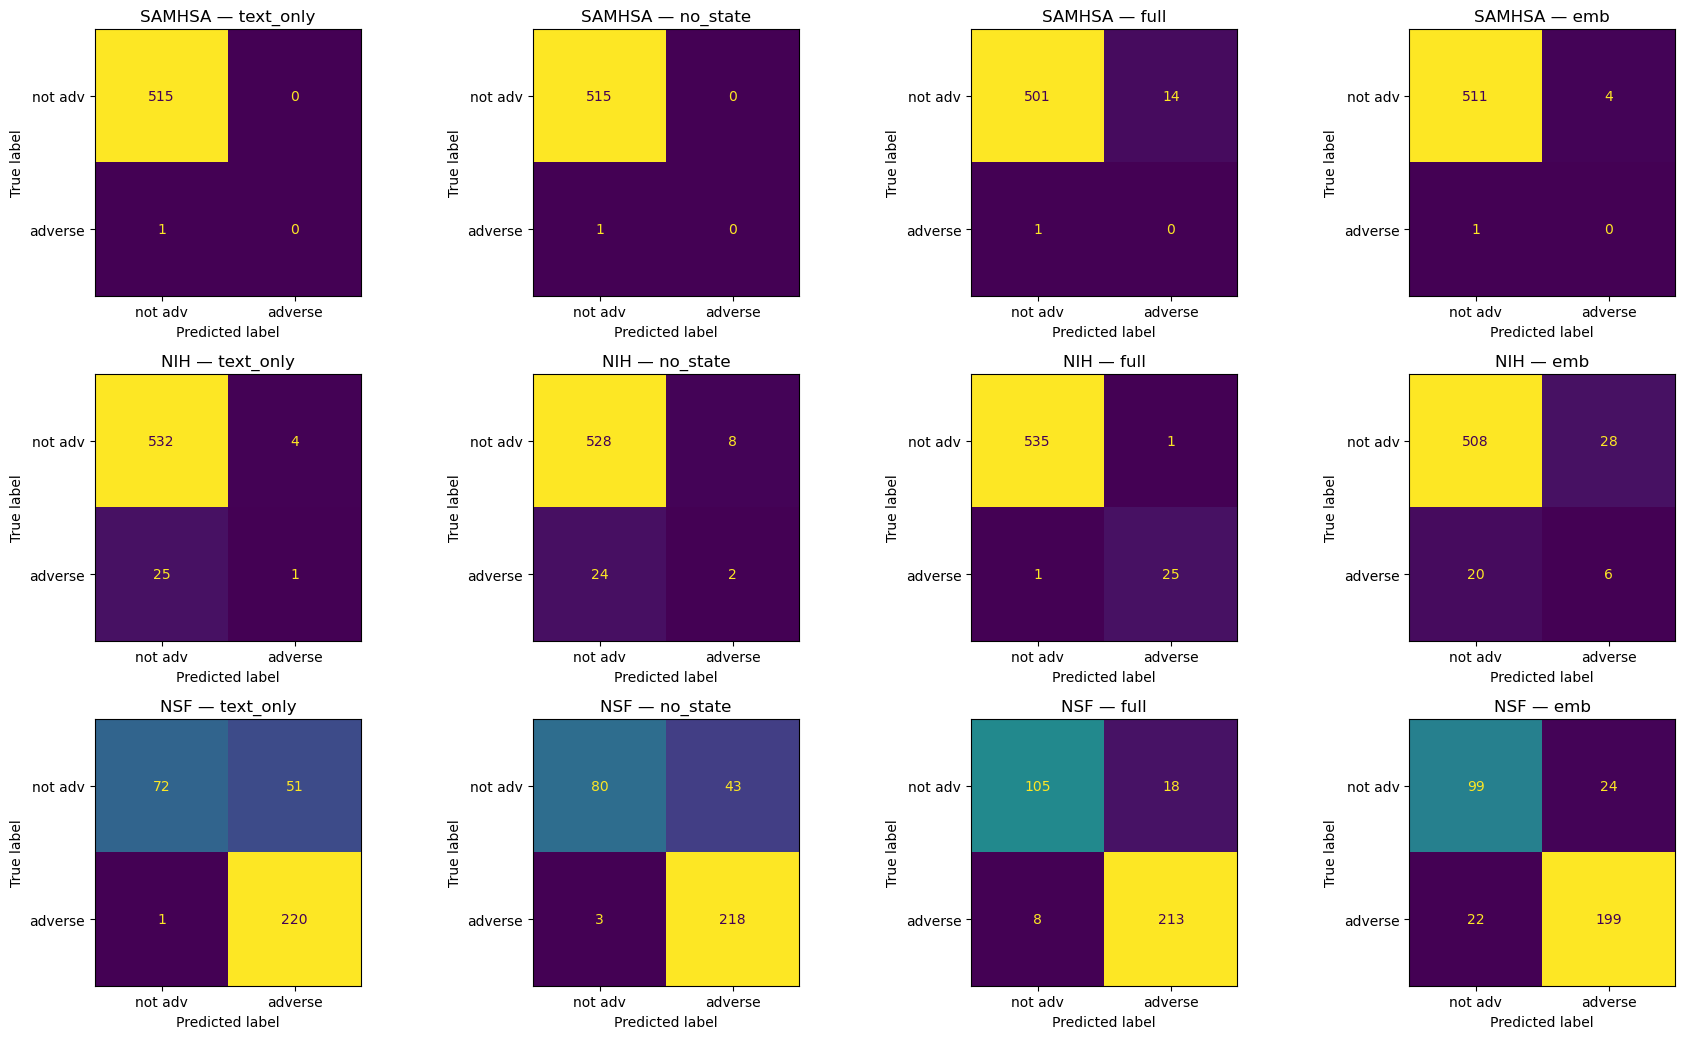

In [ ]:
agencies = df['agency'].dropna().unique()
fig, axes = plt.subplots(len(agencies), 4, figsize=(18, 3.5 * len(agencies)))
if len(agencies) == 1:
    axes = [axes]

for ax_row, agency in zip(axes, agencies):
    grp = df[df['agency'] == agency]
    for ax, (name, pred_col) in zip(ax_row, VARIANTS):
        ConfusionMatrixDisplay.from_predictions(
            grp['y_true'], grp[pred_col],
            display_labels=['not adv', 'adverse'],
            ax=ax, colorbar=False,
        )
        ax.set_title(f'{agency} — {name}')

plt.tight_layout()
plt.show()


## 4. TF-IDF vs embeddings agreement

In [ ]:
agree_pos  = df[(df['y_pred_text_only'] == 1) & (df['y_pred_emb'] == 1)]
agree_neg  = df[(df['y_pred_text_only'] == 0) & (df['y_pred_emb'] == 0)]
tfidf_only = df[(df['y_pred_text_only'] == 1) & (df['y_pred_emb'] == 0)]
emb_only   = df[(df['y_pred_text_only'] == 0) & (df['y_pred_emb'] == 1)]

print(f'Both flag (agree pos):        {len(agree_pos):4d}  | y_true pos: {agree_pos.y_true.sum()}')
print(f'Neither flags (agree neg):    {len(agree_neg):4d}  | y_true pos: {agree_neg.y_true.sum()}')
print(f'TF-IDF only flags:            {len(tfidf_only):4d}  | y_true pos: {tfidf_only.y_true.sum()}')
print(f'Embeddings only flags:        {len(emb_only):4d}  | y_true pos: {emb_only.y_true.sum()}')


Both flag (agree pos):         219  | y_true pos: 199
Neither flags (agree neg):    1104  | y_true pos: 21
TF-IDF only flags:              57  | y_true pos: 22
Embeddings only flags:          42  | y_true pos: 6


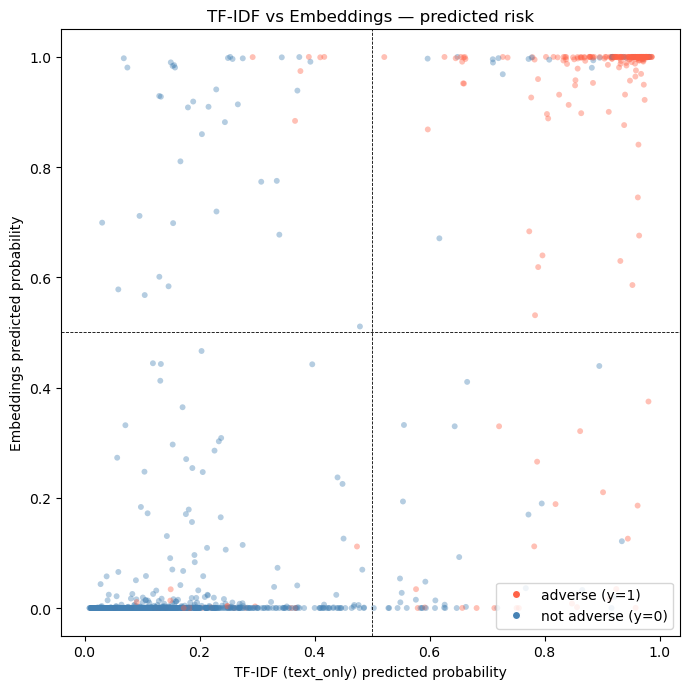

In [ ]:
fig, ax = plt.subplots(figsize=(7, 7))
colors = df['y_true'].map({0: 'steelblue', 1: 'tomato'})
ax.scatter(df['y_prob_text_only'], df['y_prob_emb'],
           c=colors, alpha=0.4, s=18, linewidths=0)
ax.axhline(0.5, color='black', linewidth=0.6, linestyle='--')
ax.axvline(0.5, color='black', linewidth=0.6, linestyle='--')
ax.set_xlabel('TF-IDF (text_only) predicted probability')
ax.set_ylabel('Embeddings predicted probability')
ax.set_title('TF-IDF vs Embeddings — predicted risk')
from matplotlib.lines import Line2D
ax.legend(handles=[
    Line2D([0],[0], marker='o', color='w', markerfacecolor='tomato',   label='adverse (y=1)'),
    Line2D([0],[0], marker='o', color='w', markerfacecolor='steelblue', label='not adverse (y=0)'),
], loc='lower right')
plt.tight_layout()
plt.show()


### TF-IDF flags, embeddings don't (`y_pred_text_only=1`, `y_pred_emb=0`)

In [ ]:
show = [c for c in ['agency', 'org_state', 'y_true',
                     'y_prob_text_only', 'y_prob_emb',
                     'num_flagged_words_total', 'flagged_ratio',
                     'project_title', 'abstract'] if c in df.columns]

print(f'TF-IDF only flags: {len(tfidf_only)} records')
tfidf_only.sort_values('y_prob_text_only', ascending=False)[show].head(20)


TF-IDF only flags: 57 records


,agency,org_state,y_true,y_prob_text_only,y_prob_emb,num_flagged_words_total,flagged_ratio,project_title,abstract
6663,NSF,TX,1,0.980766,0.374699,11,0.021195,CIMA LSAMP Alliance,The Louis Stokes Alliances for Minority Participation (LSAMP) program assists universities and colleges in their eff...
6857,NSF,CA,1,0.961879,0.185864,12,0.022472,HSI Institutional Transformation Project: Cal Poly Pomona INtentional Venture Engaging STEM Students (CPP INVESTS),"With support from the Improving Undergraduate STEM Education: Hispanic-Serving Institutions (HSI Program), this Trac..."
6597,NSF,LA,1,0.958401,0.000307,11,0.018152,Louis Stokes Regional Center of Excellence: LSAMP - NSF International Center of Excellence (NICE),The Louis Stokes Regional NSF International Center of Excellence (LSAMP-NICE)\n\nThe goal of the Louis Stokes Region...
7318,NSF,CA,1,0.944879,0.125868,3,0.007160,Support Partnership for New Bilingual Science and Engineering Teachers,"This project examines how Latine, bilingual teachers' dispositions to teach science and engineering to bilingual lea..."
7790,NSF,CA,0,0.934477,0.121202,7,0.013592,Conference: Promoting Equity through Localization and High-Quality Instructional Materials: Bringing Together Practi...,"Over the last decade, K-12 science education has seen the development and surge in comprehensive high-quality instru..."
7687,NSF,NY,1,0.924732,0.034454,7,0.015119,Recentering the experiences of STEM majors with dis/abilities in college: Investigating systemic factors that enable...,This project will investigate how higher education structures enable or disable diverse STEM students with dis/abili...
6842,NSF,CA,0,0.921670,0.020256,15,0.025338,ADVANCE Partnership: Promoting Equity and Inclusion to Facilitate Retention of Faculty through Evidence- and Place-B...,"The University of California, Riverside (UCR) Collaborative NSF ADVANCE Partnership project (COE ADVANCE) aims at de..."
6144,NSF,CA,0,0.916463,0.000061,7,0.015556,Collaborative Research: Build and Broaden 2.0: California Alliance for Hispanic-serving Social Science Advancement (...,This award is funded in whole or in part under the American Rescue Plan Act of 2021 (Public Law 117-2). \n\nThe Cali...
6143,NSF,NY,1,0.913661,0.016531,7,0.009296,A media project engaging girls in astrophysics during the 2024 total solar eclipse,The state of Americansâ STEM knowledge and competency is disappointingly low. âThe Nationâs Report Cardâ rev...
5993,NSF,PA,1,0.901747,0.210054,11,0.019231,Strength Across Schools Partnership to Teach Empowering Computational Thinking and Computer Science in Middle School...,"The Strength Across Schools Research-to-Practice Partnership (RPP), expanding an existing CS for All Research-Practi..."


In [ ]:
for _, row in tfidf_only.sort_values('y_prob_text_only', ascending=False).iterrows():
    print(f'[{row.get("agency","")}] y_true={int(row.y_true)}  '
          f'tfidf={row.y_prob_text_only:.3f}  emb={row.y_prob_emb:.3f}')
    print(str(row.get('project_title', ''))[:120])
    if 'abstract' in df.columns and pd.notna(row.get('abstract')):
        print(str(row['abstract']))
    print()


[NSF] y_true=1  tfidf=0.981  emb=0.375
CIMA LSAMP Alliance
The Louis Stokes Alliances for Minority Participation (LSAMP) program assists universities and colleges in their efforts to significantly increase the number of students matriculating into and successfully completing high quality degree programs in science,technology, engineering and mathematics (STEM) disciplines in order to diversify the STEM workforce.  Particular emphasis is placed on transforming undergraduate STEM education through innovative, evidence-based recruitment and retention strategies, and relevant educational experiences in support of racial and ethnic groups historically underrepresented in STEM disciplines: African Americans, Hispanic Americans,American Indians, Alaska Natives, Native Hawaiians, and Native Pacific Islanders. These strategies facilitate the production of well-prepared students highly-qualified and motivated to pursue graduate education or careers in STEM.  For the United States (U.S.) to remai

### Embeddings flag, TF-IDF doesn't (`y_pred_emb=1`, `y_pred_text_only=0`)

In [ ]:
print(f'Embeddings only flags: {len(emb_only)} records')
emb_only.sort_values('y_prob_emb', ascending=False)[show].head(20)


Embeddings only flags: 42 records


,agency,org_state,y_true,y_prob_text_only,y_prob_emb,num_flagged_words_total,flagged_ratio,project_title,abstract
2937,NIH,NC,1,0.389952,0.999991,3,0.008621,Biogenesis and function of retrotransposon-derived circular DNA,ABSTRACT Retrotransposons are highly enriched in animal genome. Their activation can rewrite the host genetic inform...
4200,NIH,NC,1,0.416796,0.999986,1,0.003012,Characterizing new redox roles for protein ubiquitination in human cells,PROJECT SUMMARY Human cells are constantly subjected to oxidative stress due to the exposure to solar UV radiation a...
2012,NIH,NY,0,0.253104,0.999957,4,0.010989,Biomimetic approaches for enthesis tissue engineering,"ABSTRACT Rotator cuff tears are prevalent, particularly in the elderly population, and typically require surgical re..."
2042,NIH,NY,0,0.373382,0.999727,5,0.020243,Synthetic biology to discover kratom natural product biosynthetic pathways for biased analgesic development,Project Summary Opioid alternative analgesics that would kill pain potently without the respiratory side effect wil...
1839,NIH,NC,1,0.292250,0.999600,9,0.020408,Genetic Contributors to the Impact of Sex on Heterogeneity in Flu Infection,Project Summary/Abstract The 1918 influenza pandemic is estimated to have killed 1 in 20 people worldwide. Influenz...
5022,NIH,NC,1,0.409821,0.999251,2,0.004320,Stimulating Access to Research in Residency (StARR) - NIAID,The physician-scientist workforce has been an important driver for many of the substantial discoveries in infectious...
2233,NIH,IL,0,0.342906,0.999185,3,0.006085,A novel role for EZH2 in A-to-I RNA editing in prostate cancer,"Abstract Prostate cancer is one of the most common cancers among men, and although it can successfully be treated i..."
2388,NIH,IL,0,0.249329,0.997960,0,0.000000,Molecular Mechanisms of Tonotopy Development in the Brain Stem,"ABSRACT Normal nervous system maturation is dependent on neurotrophin signaling. Neurotrophins are proteins, and alo..."
3574,NIH,NY,0,0.068077,0.997525,2,0.004525,Neural Mechanisms of Reading Dysfunction in Schizophrenia,Schizophrenia (Sz) is associated with deficits in reading ability that interrelate with disturbances in early audito...
5877,NIH,MA,0,0.275046,0.997358,3,0.011070,"Mind the Gap: Addressing ""Missing Pieces"" in Neuroscience Curricula to Reinforce Research Rigor",ABSTRACT The PhD Program in Neuroscience at Harvard University has been a leader in the development of innovative cu...


In [ ]:
for _, row in emb_only.sort_values('y_prob_emb', ascending=False).iterrows():
    print(f'[{row.get("agency","")}] y_true={int(row.y_true)}  '
          f'tfidf={row.y_prob_text_only:.3f}  emb={row.y_prob_emb:.3f}')
    print(str(row.get('project_title', ''))[:120])
    if 'abstract' in df.columns and pd.notna(row.get('abstract')):
        print(str(row['abstract']))
    print()


[NIH] y_true=1  tfidf=0.390  emb=1.000
Biogenesis and function of retrotransposon-derived circular DNA
ABSTRACT Retrotransposons are highly enriched in animal genome. Their activation can rewrite the host genetic information and fundamentally impact host biology. While developmental activation of retrotransposons can bring hosts benefits, such as against virus infection, uncontrolled activation promotes diseases or potentially drives aging. Despite their abundance and fundamental impacts on host physiology and pathology, the study of retrotransposons remains an underexplored area of biomedical research. Using new tools and biological systems developed by my team, in the long-term, we aim to characterize the retrotransposon replication cycle and explore the impact of their activation to the hosts under physiological and pathological conditions. Upon activation, retrotransposons use their mRNA as templates to synthesize double-stranded DNA for making new insertions in the host genome. Wh

## 5. TF-IDF vocabulary per agency

Re-fits the text-only TF-IDF + LR on the full training set to extract feature weights and per-agency discriminative terms. This shows what vocabulary each agency's at-risk grants actually contain — and whether the model is learning content risk or administrative artefacts.

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

df_all = pd.read_csv('00_data/03_full.csv')
if 'project_title' in df_all.columns:
    df_all['all_text'] = (df_all['project_title'].fillna('') + ' ' +
                          df_all['abstract'].fillna('')).str.strip()
else:
    df_all['all_text'] = df_all['abstract'].fillna('')

df_all = df_all.dropna(subset=['target_adverse'])
df_all = df_all[df_all['all_text'].str.len() > 10]

train_idx, _ = train_test_split(
    df_all.index, test_size=0.2, random_state=42,
    stratify=df_all['target_adverse']
)
df_tr = df_all.loc[train_idx]

tfidf_vocab = TfidfVectorizer(max_features=10_000, ngram_range=(1, 2),
                               sublinear_tf=True, stop_words='english')
X_vocab = tfidf_vocab.fit_transform(df_tr['all_text'])
lr_vocab = LogisticRegression(penalty='l2', solver='lbfgs',
                               max_iter=5000, class_weight='balanced')
lr_vocab.fit(X_vocab, df_tr['target_adverse'])

feat_names = np.array(tfidf_vocab.get_feature_names_out())
coefs      = lr_vocab.coef_[0]
print(f'Vocabulary size: {len(feat_names):,}')
print(f'Train agencies: {df_tr["agency"].value_counts().to_dict()}')


Vocabulary size: 10,000
Train agencies: {'NIH': 4803, 'SAMHSA': 2133, 'NSF': 1583, 'EPA': 537}


### Overall top LR coefficients

In [ ]:
TOP_N = 30
top_pos_idx = np.argsort(coefs)[-TOP_N:][::-1]
top_neg_idx = np.argsort(coefs)[:TOP_N]

df_pos_terms = pd.DataFrame({'term': feat_names[top_pos_idx],
                              'coef': coefs[top_pos_idx].round(4)})
df_neg_terms = pd.DataFrame({'term': feat_names[top_neg_idx],
                              'coef': coefs[top_neg_idx].round(4)})

print(f'Top {TOP_N} adverse terms:')
print(df_pos_terms.to_string(index=False))
print(f'\nTop {TOP_N} non-adverse terms:')
print(df_neg_terms.to_string(index=False))


Top 30 adverse terms:
              term   coef
              duke 3.3147
             block 2.5808
        supplement 2.5779
            equity 2.1437
         agreement 2.0215
          abstract 2.0127
            gender 1.9044
        activities 1.9012
         diversity 1.8187
  underrepresented 1.7856
            parent 1.7496
activities include 1.7394
              stem 1.7261
      subrecipient 1.7217
       description 1.6514
               lab 1.6255
  community mental 1.6184
       experiences 1.5877
           predict 1.5671
   duke university 1.5469
          auditory 1.5446
             virus 1.5133
      professional 1.4703
      institutions 1.4622
             black 1.4346
               scd 1.4329
agreement provides 1.4162
          proposal 1.4075
     environmental 1.4071
      deliverables 1.4067

Top 30 non-adverse terms:
                 term    coef
           california -2.8188
                youth -2.3333
             recovery -2.3190
                 ucla -2.

### Per-agency: terms most discriminative between at-risk and non-at-risk grants

In [ ]:
agencies = [a for a in ['NIH', 'NSF', 'SAMHSA', 'EPA']
             if a in df_tr['agency'].values]

agency_dfs = {}
agency_pos_means = {}

for agency in agencies:
    ag_pos = df_tr[(df_tr['agency'] == agency) & (df_tr['target_adverse'] == 1)]
    ag_neg = df_tr[(df_tr['agency'] == agency) & (df_tr['target_adverse'] == 0)]
    if len(ag_pos) < 5:
        print(f'{agency}: too few positives ({len(ag_pos)}), skipping')
        continue
    mean_pos = np.asarray(tfidf_vocab.transform(ag_pos['all_text']).mean(axis=0)).flatten()
    mean_neg = np.asarray(tfidf_vocab.transform(ag_neg['all_text']).mean(axis=0)).flatten()
    diff = mean_pos - mean_neg
    top_idx = np.argsort(diff)[-20:][::-1]
    agency_pos_means[agency] = mean_pos
    agency_dfs[agency] = pd.DataFrame({
        'term': feat_names[top_idx],
        'diff': diff[top_idx].round(5),
        'mean_pos': mean_pos[top_idx].round(5),
        'mean_neg': mean_neg[top_idx].round(5),
    })
    print(f'\n--- {agency} (pos={len(ag_pos)}, neg={len(ag_neg)}) ---')
    print(agency_dfs[agency].to_string(index=False))



--- NIH (pos=1076, neg=3727) ---
               term    diff  mean_pos  mean_neg
         biomedical 0.01020   0.01744   0.00725
           students 0.00820   0.01357   0.00537
          diversity 0.00734   0.01176   0.00442
   underrepresented 0.00720   0.00999   0.00279
             career 0.00699   0.01491   0.00793
           research 0.00680   0.02994   0.02314
         supplement 0.00631   0.00757   0.00127
           graduate 0.00628   0.00989   0.00361
            program 0.00616   0.01705   0.01089
           sciences 0.00601   0.00995   0.00394
      undergraduate 0.00579   0.00744   0.00165
                 ur 0.00577   0.00688   0.00111
biomedical research 0.00569   0.00893   0.00323
               duke 0.00567   0.00584   0.00017
            careers 0.00546   0.00895   0.00348
          workforce 0.00533   0.00733   0.00200
         scientific 0.00494   0.01221   0.00727
       professional 0.00492   0.00836   0.00344
biomedical sciences 0.00488   0.00632   0.00143
      

In [ ]:
top50_idx = np.argsort(coefs)[-50:][::-1]

rows = []
for i in top50_idx:
    means = {ag: agency_pos_means.get(ag, np.zeros(len(feat_names)))[i]
             for ag in agencies}
    dominant = max(means, key=means.get)
    row = {'term': feat_names[i], 'coef': round(coefs[i], 4), 'dominant': dominant}
    row.update({ag: round(means[ag], 4) for ag in agencies})
    rows.append(row)

df_xagency = pd.DataFrame(rows)[['term', 'coef'] + agencies + ['dominant']]
print(df_xagency.to_string(index=False))


                term   coef    NIH    NSF  SAMHSA    EPA dominant
                duke 3.3147 0.0058 0.0000  0.0000 0.0000      NIH
               block 2.5808 0.0018 0.0002  0.3998 0.0013   SAMHSA
          supplement 2.5779 0.0076 0.0002  0.0000 0.0004      NIH
              equity 2.1437 0.0049 0.0307  0.0044 0.0087      NSF
           agreement 2.0215 0.0000 0.0001  0.0000 0.0519      EPA
            abstract 2.0127 0.0177 0.0005  0.0000 0.0001      NIH
              gender 1.9044 0.0052 0.0158  0.0000 0.0000      NSF
          activities 1.9012 0.0079 0.0140  0.0000 0.0504      EPA
           diversity 1.8187 0.0118 0.0183  0.0000 0.0006      NSF
    underrepresented 1.7856 0.0100 0.0242  0.0000 0.0001      NSF
              parent 1.7496 0.0059 0.0006  0.0000 0.0007      NIH
  activities include 1.7394 0.0010 0.0018  0.0000 0.0267      EPA
                stem 1.7261 0.0060 0.0626  0.0000 0.0009      NSF
        subrecipient 1.7217 0.0000 0.0000  0.0000 0.0443      EPA
         d

In [ ]:
# Count how many of the top 50 terms are dominated by each agency
dom_counts = df_xagency['dominant'].value_counts()
print('Top-50 adverse terms dominated by agency:')
print(dom_counts.to_string())
print()
for agency in agencies:
    ag_terms = df_xagency[df_xagency['dominant'] == agency]['term'].tolist()
    print(f'{agency}: {ag_terms}')


Top-50 adverse terms dominated by agency:
dominant
NIH       17
EPA       16
NSF       15
SAMHSA     2

NIH: ['duke', 'supplement', 'abstract', 'parent', 'lab', 'predict', 'duke university', 'auditory', 'virus', 'scd', 'proposal', 'diversity supplement', 'aging', 'applicable', 'psychological', 'host', 'poor']
NSF: ['equity', 'gender', 'diversity', 'underrepresented', 'stem', 'experiences', 'professional', 'institutions', 'black', 'workforce', 'findings', 'inclusive', 'political', 'development', 'stem education']
SAMHSA: ['block', 'community mental']
EPA: ['agreement', 'activities', 'activities include', 'subrecipient', 'description', 'agreement provides', 'environmental', 'deliverables', 'air quality', 'texas', 'include', 'indoor', 'ej', 'beneficiaries', 'outcomes', 'air']


## 6. What metadata adds on top of text

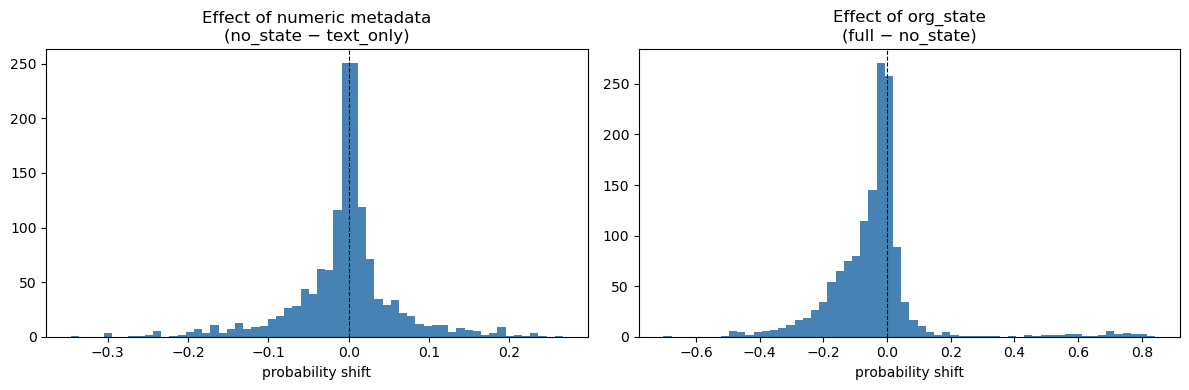

diff_meta summary:
count    1422.0000
mean       -0.0047
std         0.0649
min        -0.3459
25%        -0.0240
50%        -0.0000
75%         0.0166
max         0.2666
Name: diff_meta, dtype: float64
diff_state summary:
count    1422.0000
mean       -0.0426
std         0.1579
min        -0.7021
25%        -0.1070
50%        -0.0296
75%         0.0002
max         0.8426
Name: diff_state, dtype: float64


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, col, title in [
    (axes[0], 'diff_meta',  'Effect of numeric metadata\n(no_state − text_only)'),
    (axes[1], 'diff_state', 'Effect of org_state\n(full − no_state)'),
]:
    ax.hist(df[col], bins=60, color='steelblue', edgecolor='none')
    ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
    ax.set_xlabel('probability shift')
    ax.set_title(title)

plt.tight_layout()
plt.show()
print('diff_meta summary:');  print(df['diff_meta'].describe().round(4))
print('diff_state summary:'); print(df['diff_state'].describe().round(4))


In [ ]:
flipped_by_state = df[df['y_pred_full'] != df['y_pred_no_state']]
print(f'Predictions flipped by org_state: {len(flipped_by_state)} ({len(flipped_by_state)/len(df)*100:.1f}%)')

flip_cols = [c for c in ['agency', 'org_state', 'y_true',
                          'y_pred_no_state', 'y_pred_full',
                          'y_prob_no_state', 'y_prob_full', 'diff_state',
                          'project_title'] if c in df.columns]
flipped_by_state.sort_values('diff_state', ascending=False)[flip_cols]


Predictions flipped by org_state: 80 (5.6%)


,agency,org_state,y_true,y_pred_no_state,y_pred_full,y_prob_no_state,y_prob_full,diff_state,project_title
667,NIH,NC,1,0,1,0.129915,0.972481,0.842566,Assessing the Impact of Patient-Provider Interactions on the Cardiovascular and Cognitive Health of Aging Adults
2518,NIH,NC,1,0,1,0.081939,0.894320,0.812381,Mechanisms of mechanically-induced acute pancreatitis
10324,SAMHSA,NC,0,0,1,0.051479,0.848194,0.796715,Sober Truth on Preventing Underage Drinking Act Grants
1718,NIH,NC,1,0,1,0.103034,0.897004,0.793970,Role of IRGM proteins in immunity to enteric bacteria
8809,SAMHSA,NC,0,0,1,0.108184,0.891254,0.783070,Mental Health Awareness Training Grants
...,...,...,...,...,...,...,...,...,...
7905,NSF,CA,1,1,0,0.821422,0.336122,-0.485300,Collaborative Research: ReDDDoT Phase 2: Inclusive American language technologies
6327,NSF,CA,0,1,0,0.622503,0.134891,-0.487612,Deep learning-based serological test for point-of-care analysis of COVID-19 immunity with a paper-based multiplexed ...
6472,NSF,CA,0,1,0,0.651014,0.155463,-0.495551,The Dynamics of Unique Decisions
6311,NSF,CA,0,1,0,0.757635,0.245694,-0.511940,BRITE Fellow: Systems-level Mechanobiology from the Cellular Mechanome to Sustainable Meat Production


In [44]:
if 'org_state' in df.columns:
    state_stats = df.groupby('org_state').agg(
        n=('y_true', 'count'),
        pos_rate=('y_true', 'mean'),
        mean_prob_full=('y_prob_full', 'mean'),
        mean_prob_no_state=('y_prob_no_state', 'mean'),
        mean_diff_state=('diff_state', 'mean'),
    ).round(4).sort_values('mean_diff_state', ascending=False)
    filtered = state_stats[state_stats['n'] >= 5]
    print('States boosted by org_state (top 15):')
    print(filtered.head(15).to_string())
    print('\nStates suppressed by org_state (bottom 15):')
    print(filtered.tail(15).to_string())


States boosted by org_state (top 15):
            n  pos_rate  mean_prob_full  mean_prob_no_state  mean_diff_state
org_state                                                                   
NC         49    0.6939          0.8754              0.3272           0.5483
PR          6    0.3333          0.2872              0.2392           0.0480
DC         11    0.7273          0.7437              0.6991           0.0446
CO         19    0.6842          0.6834              0.6411           0.0422
PA         29    0.3793          0.4323              0.3909           0.0414
AZ         17    0.2353          0.3162              0.2749           0.0413
VA         21    0.3810          0.4545              0.4146           0.0399
MD         15    0.2667          0.2959              0.2563           0.0396
MN          6    0.5000          0.5121              0.4738           0.0383
WI          8    0.0000          0.0842              0.0522           0.0321
WA         21    0.3810          0.390

## 6b. Per-agency feature-group ablation

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.metrics import average_precision_score, roc_auc_score
import warnings; warnings.filterwarnings('ignore')

# Load full dataset (two-step: load then drop embedding columns)
df_abl = pd.read_csv('00_data/03_full.csv')

# Derive missing columns
df_abl['all_text'] = (
    df_abl['project_title'].fillna('') + ' ' + df_abl['abstract'].fillna('')
).str.strip()
df_abl['log_total_award'] = np.log1p(
    df_abl[['award_amount','award_outlaid','award_remaining']].fillna(0).clip(lower=0).sum(axis=1)
)
if 'start_date_original' in df_abl.columns:
    df_abl['start_year'] = pd.to_datetime(df_abl['start_date_original'], errors='coerce').dt.year
else:
    df_abl['start_year'] = np.nan
df_abl['text_len']            = df_abl['all_text'].str.len()
df_abl['abstract_len']        = df_abl['abstract'].fillna('').str.len()
df_abl['title_len']           = df_abl['project_title'].fillna('').str.len()
df_abl['abstract_word_count'] = df_abl['abstract'].fillna('').str.split().str.len()
df_abl['flagged_ratio'] = (
    df_abl['num_flagged_words_total'] / df_abl['text_len'].replace(0, np.nan)
).fillna(0)

# Feature group definitions (filter to available columns)
_avail = set(df_abl.columns)
financial_cols = [c for c in ['award_amount','award_outlaid','award_remaining','log_total_award']
                  if c in _avail]
keyword_cols   = [c for c in ['num_flagged_words_total','num_pen_words','num_pen_words_total',
                               'num_nyt_words','num_nyt_words_total','has_flagged_word_total',
                               'n_banned_terms_total','flagged_ratio'] if c in _avail]
temporal_cols  = [c for c in ['start_year'] if c in _avail]
text_prop_cols = [c for c in ['text_len','abstract_len','title_len','abstract_word_count']
                  if c in _avail]
inst_cats      = [c for c in ['org_state'] if c in _avail]
all_meta_num   = financial_cols + keyword_cols + temporal_cols + text_prop_cols

df_abl = df_abl.dropna(subset=['target_adverse','all_text'])

# Replicate the same 80/20 split as 04_modeling
train_idx_abl, test_idx_abl = train_test_split(
    df_abl.index, test_size=0.2, random_state=42, stratify=df_abl['target_adverse']
)
df_tr_abl = df_abl.loc[train_idx_abl]
df_te_abl = df_abl.loc[test_idx_abl]

ablation_conditions = {
    'Text only':            ([], []),
    'Text + financial':     (financial_cols, []),
    'Text + keyword risk':  (keyword_cols, []),
    'Text + temporal':      (temporal_cols, []),
    'Text + institutional': ([], inst_cats),
    'Text + text props':    (text_prop_cols, []),
    'Text + all metadata':  (all_meta_num, inst_cats),
}

print(f'Train: {len(df_tr_abl):,} | Test: {len(df_te_abl):,}')
print(f'financial: {financial_cols}')
print(f'keyword:   {keyword_cols}')
print(f'temporal:  {temporal_cols}')
print(f'text_prop: {text_prop_cols}')
print(f'inst_cats: {inst_cats}')


Train: 9,056 | Test: 2,265
financial: ['award_amount', 'award_outlaid', 'award_remaining', 'log_total_award']
keyword:   ['num_flagged_words_total', 'num_pen_words', 'num_pen_words_total', 'num_nyt_words', 'num_nyt_words_total', 'has_flagged_word_total', 'n_banned_terms_total', 'flagged_ratio']
temporal:  ['start_year']
text_prop: ['text_len', 'abstract_len', 'title_len', 'abstract_word_count']
inst_cats: ['org_state']


In [ ]:
def _num_pre(cols):
    return [('num', Pipeline([('imp', SimpleImputer(strategy='median')),
                               ('sc',  StandardScaler())]), cols)]

def build_pipe(num_cols, cat_cols, text_col='all_text'):
    transformers = [('tfidf', TfidfVectorizer(max_features=10_000, ngram_range=(1,2),
                                               sublinear_tf=True, stop_words='english'),
                     text_col)]
    if num_cols:
        transformers.extend(_num_pre(num_cols))
    if cat_cols:
        transformers.append(('cat', OneHotEncoder(handle_unknown='ignore',
                                                   sparse_output=False), cat_cols))
    pre = ColumnTransformer(transformers, remainder='drop', sparse_threshold=0)
    return Pipeline([('pre', pre),
                     ('lr',  LogisticRegression(penalty='l2', solver='lbfgs',
                                                max_iter=5000, class_weight='balanced'))])

input_cols_abl = ['all_text'] + all_meta_num + inst_cats
print('Pipeline builder ready.')


Pipeline builder ready.


In [46]:
abl_agency_results = []

for agency in ['NIH', 'NSF', 'SAMHSA', 'EPA']:
    df_ag_tr = df_tr_abl[df_tr_abl['agency'] == agency]
    df_ag_te = df_te_abl[df_te_abl['agency'] == agency]
    y_ag_tr  = df_ag_tr['target_adverse'].values
    y_ag_te  = df_ag_te['target_adverse'].values
    n_pos    = int(y_ag_tr.sum())
    n_neg    = int((y_ag_tr == 0).sum())

    print(f'\n{agency}  train={len(y_ag_tr)} ({n_pos} pos)  test={len(y_ag_te)} ({int(y_ag_te.sum())} pos)')

    if n_pos < 3 or n_neg < 3:
        print('  Skipping: too few samples')
        continue

    n_splits = min(5, n_pos, n_neg)
    skf_ag   = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

    for cond_name, (num_c, cat_c) in ablation_conditions.items():
        # Drop columns that are all-NaN for this agency's training slice
        valid_num = [c for c in num_c if df_ag_tr[c].notna().any()]
        valid_cat = [c for c in cat_c if df_ag_tr[c].notna().any()]
        cols_needed = ['all_text'] + valid_num + valid_cat

        pipe = build_pipe(valid_num, valid_cat)
        X_tr = df_ag_tr[cols_needed]
        X_te = df_ag_te[cols_needed]

        cv = cross_validate(pipe, X_tr, y_ag_tr, cv=skf_ag,
                            scoring=['roc_auc', 'average_precision'],
                            return_train_score=False)
        pipe.fit(X_tr, y_ag_tr)

        has_both = y_ag_te.sum() >= 2 and (y_ag_te == 0).sum() >= 2
        if has_both:
            y_prob     = pipe.predict_proba(X_te)[:, 1]
            test_aucpr = round(average_precision_score(y_ag_te, y_prob), 4)
            test_auc   = round(roc_auc_score(y_ag_te, y_prob), 4)
        else:
            test_aucpr = test_auc = float('nan')

        cv_aucpr = round(cv['test_average_precision'].mean(), 4)
        cv_auc   = round(cv['test_roc_auc'].mean(), 4)

        abl_agency_results.append({
            'agency': agency, 'condition': cond_name,
            'cv_auc': cv_auc, 'cv_aucpr': cv_aucpr,
            'test_auc': test_auc, 'test_aucpr': test_aucpr,
        })
        print(f'  {cond_name:<24}  CV AUC-PR={cv_aucpr:.4f}  Test AUC-PR={test_aucpr}')

df_abl_agency = pd.DataFrame(abl_agency_results)



NIH  train=4803 (1076 pos)  test=1187 (273 pos)
  Text only                 CV AUC-PR=0.5594  Test AUC-PR=0.5031
  Text + financial          CV AUC-PR=0.5756  Test AUC-PR=0.5136
  Text + keyword risk       CV AUC-PR=0.5446  Test AUC-PR=0.4946
  Text + temporal           CV AUC-PR=0.5594  Test AUC-PR=0.5031
  Text + institutional      CV AUC-PR=0.7949  Test AUC-PR=0.8177
  Text + text props         CV AUC-PR=0.5584  Test AUC-PR=0.5023
  Text + all metadata       CV AUC-PR=0.8063  Test AUC-PR=0.824

NSF  train=1583 (1092 pos)  test=408 (270 pos)
  Text only                 CV AUC-PR=0.9528  Test AUC-PR=0.9503
  Text + financial          CV AUC-PR=0.9494  Test AUC-PR=0.9455
  Text + keyword risk       CV AUC-PR=0.9481  Test AUC-PR=0.9426
  Text + temporal           CV AUC-PR=0.9524  Test AUC-PR=0.9496
  Text + institutional      CV AUC-PR=0.9853  Test AUC-PR=0.968
  Text + text props         CV AUC-PR=0.9526  Test AUC-PR=0.9473
  Text + all metadata       CV AUC-PR=0.9807  Test AUC-PR=0.

In [47]:
# Pivot: conditions as rows, agencies as columns (test AUC-PR)
pivot_aucpr = df_abl_agency.pivot(index='condition', columns='agency',
                                   values='test_aucpr').round(4)
# Keep condition order
cond_order = list(ablation_conditions.keys())
pivot_aucpr = pivot_aucpr.reindex(cond_order)
print('Per-agency test AUC-PR by ablation condition:')
print(pivot_aucpr.to_string())
print()
pivot_cv = df_abl_agency.pivot(index='condition', columns='agency',
                                values='cv_aucpr').round(4).reindex(cond_order)
print('Per-agency CV AUC-PR by ablation condition:')
print(pivot_cv.to_string())


Per-agency test AUC-PR by ablation condition:
agency                   EPA     NIH     NSF  SAMHSA
condition                                           
Text only             0.9904  0.5031  0.9503  0.5686
Text + financial      0.9917  0.5136  0.9455  0.8513
Text + keyword risk   0.9928  0.4946  0.9426  0.5574
Text + temporal       0.9904  0.5031  0.9496  0.5686
Text + institutional  0.9770  0.8177  0.9680  0.7729
Text + text props     0.9852  0.5023  0.9473  0.5686
Text + all metadata   0.9877  0.8240  0.9676  0.8648

Per-agency CV AUC-PR by ablation condition:
agency                   EPA     NIH     NSF  SAMHSA
condition                                           
Text only             0.9882  0.5594  0.9528  0.4925
Text + financial      0.9901  0.5756  0.9494  0.7511
Text + keyword risk   0.9870  0.5446  0.9481  0.5051
Text + temporal       0.9882  0.5594  0.9524  0.4551
Text + institutional  0.9877  0.7949  0.9853  0.6863
Text + text props     0.9868  0.5584  0.9526  0.4451
Text + a

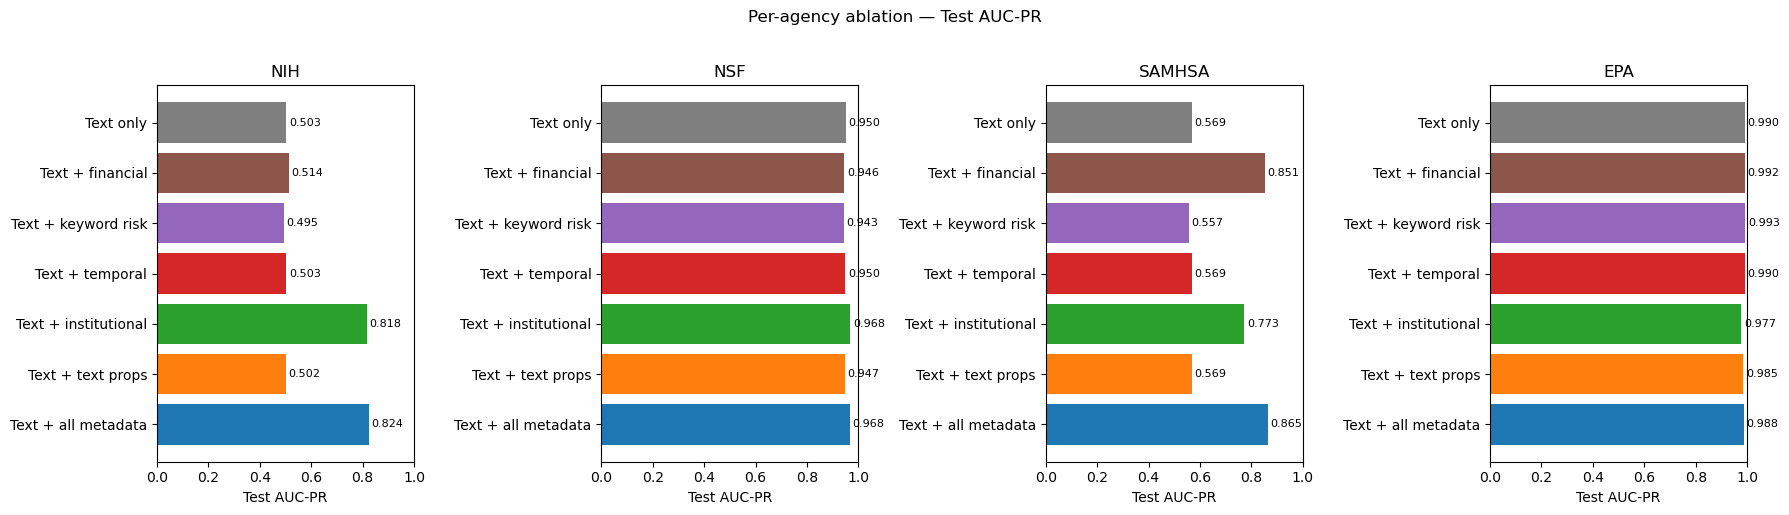

In [ ]:
agencies_plot = df_abl_agency['agency'].unique()
fig, axes = plt.subplots(1, len(agencies_plot),
                          figsize=(4.5 * len(agencies_plot), 5), sharey=False)
if len(agencies_plot) == 1:
    axes = [axes]

colors = plt.cm.tab10(np.linspace(0, 0.7, len(ablation_conditions)))

for ax, agency in zip(axes, agencies_plot):
    sub = df_abl_agency[df_abl_agency['agency'] == agency].set_index('condition')
    sub = sub.reindex(cond_order)
    bars = ax.barh(sub.index[::-1], sub['test_aucpr'][::-1], color=colors)
    ax.set_xlabel('Test AUC-PR')
    ax.set_title(agency)
    ax.set_xlim(0, 1)
    for bar, val in zip(bars, sub['test_aucpr'][::-1]):
        if not np.isnan(val):
            ax.text(val + 0.01, bar.get_y() + bar.get_height()/2,
                    f'{val:.3f}', va='center', fontsize=8)

plt.suptitle('Per-agency ablation — Test AUC-PR', y=1.02)
plt.tight_layout()
plt.show()


In [ ]:
# Gain from each feature group over text-only baseline
text_only_base = df_abl_agency[df_abl_agency['condition'] == 'Text only'].set_index('agency')['test_aucpr']
df_gain = df_abl_agency[df_abl_agency['condition'] != 'Text only'].copy()
df_gain['gain'] = df_gain.apply(
    lambda r: round(r['test_aucpr'] - text_only_base.get(r['agency'], float('nan')), 4), axis=1
)
pivot_gain = df_gain.pivot(index='condition', columns='agency', values='gain').round(4)
pivot_gain = pivot_gain.reindex([c for c in cond_order if c != 'Text only'])
print('Gain in test AUC-PR over text-only baseline:')
print(pivot_gain.to_string())


Gain in test AUC-PR over text-only baseline:
agency                   EPA     NIH     NSF  SAMHSA
condition                                           
Text + financial      0.0013  0.0105 -0.0048  0.2827
Text + keyword risk   0.0024 -0.0085 -0.0077 -0.0112
Text + temporal       0.0000  0.0000 -0.0007  0.0000
Text + institutional -0.0134  0.3146  0.0177  0.2043
Text + text props    -0.0052 -0.0008 -0.0030  0.0000
Text + all metadata  -0.0027  0.3209  0.0173  0.2962


In [ ]:
import scipy.sparse as sp

# Rebuild full pipeline (text + all metadata) per agency
# Depends on: df_tr_abl, df_te_abl, all_meta_num, inst_cats, build_pipe (from s5c cells)

shap_agencies = ['NIH', 'NSF']
shap_store_05 = {}

for agency in shap_agencies:
    ag_tr = df_tr_abl[df_tr_abl['agency'] == agency]
    ag_te = df_te_abl[df_te_abl['agency'] == agency]
    y_tr  = ag_tr['target_adverse'].values
    y_te  = ag_te['target_adverse'].values

    valid_num = [c for c in all_meta_num if ag_tr[c].notna().any()]
    valid_cat = [c for c in inst_cats  if ag_tr[c].notna().any()]
    cols = ['all_text'] + valid_num + valid_cat

    # Build with sparse_threshold=0.5 to keep TF-IDF sparse
    from sklearn.pipeline import Pipeline as _P
    from sklearn.compose import ColumnTransformer as _CT
    from sklearn.feature_extraction.text import TfidfVectorizer as _TV
    from sklearn.preprocessing import OneHotEncoder as _OHE, StandardScaler as _SS
    from sklearn.impute import SimpleImputer as _SI
    from sklearn.linear_model import LogisticRegression as _LR

    t = [('tfidf', _TV(max_features=5_000, ngram_range=(1,2),
                       sublinear_tf=True, stop_words='english'), 'all_text')]
    if valid_num:
        t.append(('num', _P([('imp', _SI(strategy='median')), ('sc', _SS())]), valid_num))
    if valid_cat:
        t.append(('cat', _OHE(handle_unknown='ignore', sparse_output=False), valid_cat))
    pipe_shap = _P([('pre', _CT(t, remainder='drop')),
                    ('lr',  _LR(penalty='l2', solver='lbfgs', max_iter=5000,
                                class_weight='balanced'))])
    pipe_shap.fit(ag_tr[cols], y_tr)

    pre = pipe_shap.named_steps['pre']
    lr  = pipe_shap.named_steps['lr']
    feat_names = pre.get_feature_names_out()

    X_tr_t = pre.transform(ag_tr[cols])
    X_te_t = pre.transform(ag_te[cols])

    # Background mean (sparse-safe)
    bg_mean = np.asarray(X_tr_t.mean(axis=0)).ravel() if sp.issparse(X_tr_t) else X_tr_t.mean(axis=0)

    X_te_arr = X_te_t.toarray() if sp.issparse(X_te_t) else np.asarray(X_te_t)

    # Analytic linear SHAP: sv_ij = coef_j * (x_ij - mean_j)
    coef = lr.coef_[0]
    sv   = (X_te_arr - bg_mean) * coef

    shap_store_05[agency] = dict(sv=sv, feat_names=feat_names,
                                  X_te=X_te_arr, y_te=y_te)
    print(f'{agency}: {sv.shape[0]} test records, {sv.shape[1]} features')


In [50]:
sns.set_theme(style='whitegrid', font_scale=1.5)

TOP_N = 20
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, agency in zip(axes, shap_agencies):
    sv       = shap_store_05[agency]['sv']
    fn       = shap_store_05[agency]['feat_names']
    mean_abs = np.abs(sv).mean(axis=0)
    top_idx  = np.argsort(mean_abs)[-TOP_N:][::-1]

    labels = [fn[i].split('__', 1)[-1] if '__' in fn[i] else fn[i] for i in top_idx]
    vals   = mean_abs[top_idx]
    colors = ['#3B82F6' if fn[i].startswith('tfidf__') else
               '#EC4899' if fn[i].startswith('cat__')  else '#10B981'
               for i in top_idx]

    y_pos = np.arange(TOP_N) * 0.55
    bars  = ax.barh(y_pos[::-1], vals, color=colors, height=0.35,
                    edgecolor='white', linewidth=0.8)
    ax.set_yticks(y_pos[::-1])
    ax.set_yticklabels(labels, fontsize=12)
    ax.set_ylim(-0.35, (TOP_N - 1) * 0.55 + 0.35)
    ax.set_title(f'{agency} — top {TOP_N} features (mean |SHAP|)', fontsize=16, fontweight='bold', pad=11)
    ax.set_xlabel('mean |SHAP value|', fontsize=15, labelpad=12)
    ax.tick_params(axis='y', length=0)
    ax.xaxis.grid(True, linestyle='--', alpha=0.45, color='grey')
    ax.set_axisbelow(True)
    ax.set_xlim(0, vals.max() * 1.8)

    for bar, val in zip(bars, vals):
        ax.text(bar.get_width() + vals.max() * 0.015,
                bar.get_y() + bar.get_height() / 2,
                f'{val:.4f}', va='center', ha='left', fontsize=11,
                color='#333333', fontweight='medium')

    sns.despine(ax=ax, left=True, bottom=False)

from matplotlib.patches import Patch
axes[0].legend(handles=[
    Patch(color='#3B82F6', label='TF-IDF token'),
    Patch(color='#10B981', label='Numeric meta'),
    Patch(color='#EC4899', label='Categorical meta'),
], fontsize=11)

plt.tight_layout()
plt.show()


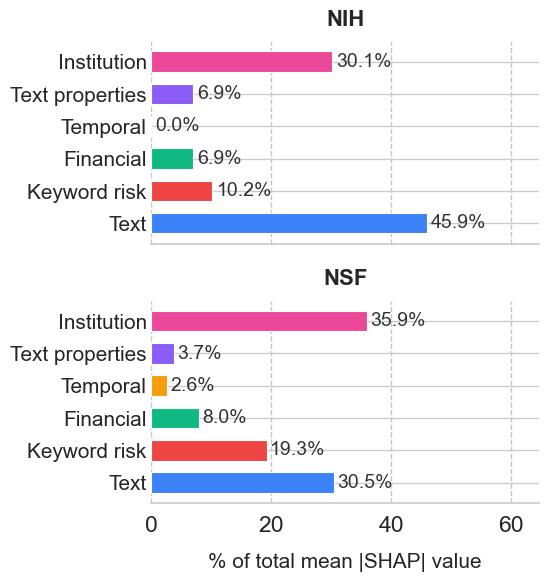


Group                      NIH       NSF
------------------------------------------
  Text                   45.9%     30.5%
  Keyword risk           10.2%     19.3%
  Financial               6.9%      8.0%
  Temporal                0.0%      2.6%
  Text properties         6.9%      3.7%
  Institution            30.1%     35.9%


In [169]:
sns.set_theme(style='whitegrid', font_scale=1.5)

_GROUP_COLS_05 = [
    ('Keyword risk',    keyword_cols),
    ('Financial',       financial_cols),
    ('Temporal',        temporal_cols),
    ('Text properties', text_prop_cols),
    ('Institution',     inst_cats),
]

def _feat_group_05(feat_name):
    if feat_name.startswith('tfidf__'):
        return 'Text'
    bare = feat_name.split('__', 1)[-1] if '__' in feat_name else feat_name
    for group, cols in _GROUP_COLS_05:
        for col in cols:
            if bare == col or bare.startswith(col + '_'):
                return group
    return 'Other'

GROUP_ORDER_05  = ['Text', 'Keyword risk', 'Financial', 'Temporal', 'Text properties', 'Institution']
GROUP_COLORS_05 = {
    'Text': '#3B82F6', 'Keyword risk': '#EF4444', 'Financial': '#10B981',
    'Temporal': '#F59E0B', 'Text properties': '#8B5CF6', 'Institution': '#EC4899',
}

fig, axes = plt.subplots(2, 1, figsize=(5, 6), sharex=True)
plt.subplots_adjust(hspace=0.28)

for ax, agency in zip(axes, shap_agencies):
    sv       = shap_store_05[agency]['sv']
    fn       = shap_store_05[agency]['feat_names']
    mean_abs = np.abs(sv).mean(axis=0)

    totals = {}
    for feat, val in zip(fn, mean_abs):
        g = _feat_group_05(feat)
        totals[g] = totals.get(g, 0.0) + val
    grand = sum(totals.values())
    pct   = {g: v / grand * 100 for g, v in totals.items()}

    groups = [g for g in GROUP_ORDER_05 if g in pct]
    vals   = [pct[g] for g in groups]
    colors = [GROUP_COLORS_05[g] for g in groups]
    y_pos  = np.arange(len(groups)) * 0.55

    bars = ax.barh(y_pos, vals, color=colors, height=0.35, edgecolor='white', linewidth=0.8)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(groups, fontsize=15)
    ax.set_ylim(-0.35, (len(groups) - 1) * 0.55 + 0.35)
    ax.set_title(f'{agency}', fontsize=16, fontweight='bold', pad=11)
    ax.tick_params(axis='y', length=0)
    ax.xaxis.grid(True, linestyle='--', alpha=0.45, color='grey')
    ax.set_axisbelow(True)

    global_max_g = max(vals)
    ax.set_xlim(0, global_max_g * 1.8)

    for bar, val in zip(bars, vals):
        ax.text(bar.get_width() + global_max_g * 0.015,
                bar.get_y() + bar.get_height() / 2,
                f'{val:.1f}%', va='center', ha='left', fontsize=14,
                color='#333333', fontweight='medium')

    sns.despine(ax=ax, left=True, bottom=False)

axes[-1].set_xlabel('% of total mean |SHAP| value', labelpad=12, fontsize=15)
plt.show()

# Summary table
print(f"\n{'Group':<20}  {'NIH':>8}  {'NSF':>8}")
print('-' * 42)
for g in GROUP_ORDER_05:
    nih_abs = np.abs(shap_store_05['NIH']['sv']).mean(axis=0)
    nsf_abs = np.abs(shap_store_05['NSF']['sv']).mean(axis=0)
    nih_fn  = shap_store_05['NIH']['feat_names']
    nsf_fn  = shap_store_05['NSF']['feat_names']
    nih_pct = nih_abs[[i for i,f in enumerate(nih_fn) if _feat_group_05(f)==g]].sum() / nih_abs.sum() * 100
    nsf_pct = nsf_abs[[i for i,f in enumerate(nsf_fn) if _feat_group_05(f)==g]].sum() / nsf_abs.sum() * 100
    print(f"  {g:<18}  {nih_pct:>7.1f}%  {nsf_pct:>7.1f}%")


## 7. False positives and false negatives

Primary analysis uses the `full` model. Columns for all four variants are included so you can see whether an error is consistent across representations or specific to one.

In [114]:
SHOW = [c for c in [
    'agency', 'org_state', 'y_true',
    'y_prob_text_only', 'y_prob_emb', 'y_prob_no_state', 'y_prob_full',
    'num_flagged_words_total', 'flagged_ratio', 'project_title', 'abstract',
] if c in df.columns]

fp = df[df['error_full'] == 'FP'].sort_values('y_prob_full', ascending=False)
fn = df[df['error_full'] == 'FN'].sort_values('y_prob_full')
print(f'FP: {len(fp)}  |  FN: {len(fn)}')


FP: 33  |  FN: 10


### False positives (full model)

In [53]:
fp[SHOW].head(20)


,agency,org_state,y_true,y_prob_text_only,y_prob_emb,y_prob_no_state,y_prob_full,num_flagged_words_total,flagged_ratio,project_title,abstract
7337,NSF,AZ,0,0.917628,1.000000e+00,0.936756,0.988482,10,0.035336,Developing Champions of Diversity with Appreciative Inquiry and Computational Simulation (CHAMPIONS),The CHAMPIONS (Developing Champions of Diversity with Appreciative Inquiry and Computational Simulation) project aim...
7780,NSF,TX,0,0.982575,9.999826e-01,0.977345,0.981966,14,0.033981,Amplifying Diverse Voices in STEM Education,Numerous studies have found that racially marginalized students in STEM and other disciplines tend to exhibit quanti...
7840,NSF,VA,0,0.942185,9.982370e-01,0.938612,0.979353,6,0.018987,Black Social and Personality Psychologists Network (BSPN),"Within the scientific disciplines of Personality and Social Psychology, a very small proportion of scholars identify..."
7792,NSF,RI,0,0.808124,9.949256e-01,0.952530,0.944310,4,0.011299,2024 Signal Transduction in Engineered Extracellular Matrices Gordon Research Conference and Seminar; Southern New H...,This award will support the 2024 Signal Transduction in Engineered Extracellular Matrices Gordon Research Conference...
11241,SAMHSA,NC,0,0.191776,1.477644e-08,0.249057,0.942967,9,0.021635,Providerâs Clinical Support System- Universities,"ECU-AMMPeD: Amplifying Medical, Midwifery, Nurse Practitioner, and Dental education aims to reduce health disparitie..."
7615,NSF,NY,0,0.709942,9.957229e-01,0.902061,0.914416,5,0.014164,"DDRIG: Ethereal infrastructure: Placelessness, nature, and low-earth-orbit satellite internet constellations",This Doctoral Dissertation Improvement Grant supports a project that examines the socio-economic and environmental c...
6203,NSF,CA,0,0.970881,9.999521e-01,0.979327,0.911420,12,0.021700,NSF INCLUDES Alliance: Inclusive Graduate Education Network,The Inclusive Graduate Education Network (IGEN) Alliance is an NSF INCLUDES Alliance involving a partnership of over...
8809,SAMHSA,NC,0,0.082482,1.559187e-06,0.108184,0.891254,6,0.021898,Mental Health Awareness Training Grants,The Faith Alliance Intervention Towards Health (F.A.I.T.H.) project is a mental health awareness initiative that wil...
7167,NSF,CA,0,0.971250,9.959373e-01,0.981005,0.888292,10,0.024155,Examining Undergraduate Research Experiences of Latinx STEM Students in Research Intensive HSIs and Emerging-HSIs,This award is funded in whole or in part under the American Rescue Plan Act of 2021 (Public Law 117-2). \n\nThis pos...
7258,NSF,MA,0,0.953813,9.999994e-01,0.964864,0.848991,11,0.023965,SPARKing Representation in Cognitive Science,"African American, Latina/o/e/x/, and Indigenous students and researchers are underrepresented in cognitive psycholog..."


In [54]:
for _, row in fp.iterrows():
    print(f'[{row.get("agency","")}] full={row.y_prob_full:.3f}  '
          f'tfidf={row.y_prob_text_only:.3f}  emb={row.y_prob_emb:.3f}')
    print(str(row.get('project_title', ''))[:120])
    if 'abstract' in df.columns and pd.notna(row.get('abstract')):
        print(str(row['abstract']))
    print()


[NSF] full=0.988  tfidf=0.918  emb=1.000
Developing Champions of Diversity with Appreciative Inquiry and Computational Simulation (CHAMPIONS)
The CHAMPIONS (Developing Champions of Diversity with Appreciative Inquiry and Computational Simulation) project aims to address the persistent lack of diversity in the geosciences field by taking a unique and inclusive approach. By embracing the principles of belonging, accessibility, justice, equity, diversity, and inclusion (BAJEDI), this project seeks to empower geosciences faculty to become catalysts for change within their departments. The significance of this project lies in its bottom-up approach, which emphasizes compassion, empathy, and the lived experiences of individual faculty members. By creating a positive and inclusive environment that values diverse viewpoints and experiences, the project aims to foster a sense of empowerment for underrepresented minority (URM) faculty, enabling them to lead from within and drive sustained progre

### False negatives (full model)

In [117]:
fn[SHOW].head(20)


,agency,org_state,y_true,y_prob_text_only,y_prob_emb,y_prob_no_state,y_prob_full,num_flagged_words_total,flagged_ratio,project_title,abstract
11111,SAMHSA,CA,1,0.052519,1.828104e-10,0.065455,0.004063,8,0.020151,Minority HIV/AIDS Fund: Integrated Behavioral Health and HIV Care for Unsheltered Populations Pilot Project,Mental illness increases the risk of HIV risk behaviors and acquisition by 4 to 10-fold. People experiencing homeles...
5055,NIH,IL,1,0.205131,2.965672e-04,0.172799,0.031697,4,0.011364,Enhancing HIV-1 vaccines by altering vaccine dose,"PROJECT SUMMARY: Developing a vaccine against HIV is thus a research priority, but it has been difficult in part bec..."
6235,NSF,CA,1,0.656869,1.589773e-04,0.705351,0.246881,5,0.016129,SCC-CIVIC-FA Track B: Everyday Respect: Measuring & Improving Communication During Motor Vehicle Stops,Traffic stops carried out by law enforcement officers include routine encounters as well as situations that hold the...
7135,NSF,MA,1,0.837583,9.998207e-01,0.643244,0.254534,0,0.000000,SaTC: Small: Core: Using Markets to Address Manipulated Information Online,Societies function poorly without free speech. They also function poorly when members cannot agree on basic facts. ...
7569,NSF,CA,1,0.596899,8.683810e-01,0.708489,0.272607,8,0.022663,RAPID: Retrospective COVID-19 Scenario Projections Accounting for Population Heterogeneities,The long-term burden of COVID-19 may vary across races and ethnicities. To address this variaiton this project will ...
7905,NSF,CA,1,0.819114,1.885625e-01,0.821422,0.336122,8,0.023460,Collaborative Research: ReDDDoT Phase 2: Inclusive American language technologies,"More than 350 languages and many additional variants and dialects are spoken in the United States and yet, voice tec..."
6719,NSF,MA,1,0.922776,9.999950e-01,0.897640,0.412594,1,0.002717,Promoting Accurate Information on Social Media,This research takes on the twin challenges of understanding what determines whether people accept or reject misleadi...
6832,NSF,CA,1,0.869262,9.985271e-01,0.834499,0.419578,2,0.005556,Collaborative Research: SaTC: CORE: Large: Rapid-Response Frameworks for Mitigating Online Disinformation,"Disinformation is a critical, pressing challenge for society. It diminishes our ability to respond to crisis events,..."
7318,NSF,CA,1,0.944879,1.258677e-01,0.901615,0.445611,3,0.007160,Support Partnership for New Bilingual Science and Engineering Teachers,"This project examines how Latine, bilingual teachers' dispositions to teach science and engineering to bilingual lea..."
7309,NSF,NY,1,0.787060,2.655334e-01,0.549464,0.451630,0,0.000000,Collaborative Research: SaTC: TTP: Medium: iDRAMA.cloud: A Platform for Measuring and Understanding Information Mani...,"Social media has become crucial to our society, especially when it comes to the rapid and broad dissemination of inf..."


In [82]:
for _, row in fn.iterrows():
    print(f'[{row.get("agency","")}] full={row.y_prob_full:.3f}  '
          f'tfidf={row.y_prob_text_only:.3f}  emb={row.y_prob_emb:.3f}')
    print(str(row.get('project_title', ''))[:120])
    if 'abstract' in df.columns and pd.notna(row.get('abstract')):
        print(str(row['abstract']))
    print()


[SAMHSA] full=0.004  tfidf=0.053  emb=0.000
Minority HIV/AIDS Fund: Integrated Behavioral Health and HIV Care for Unsheltered Populations Pilot Project
Mental illness increases the risk of HIV risk behaviors and acquisition by 4 to 10-fold. People experiencing homelessness (PEH) in Alameda County face multiple intersectional vulnerabilities and are amongst the most heavily impacted by the HIV, sexually transmitted infections (STI), hepatitis C (HCV), substance use, and mental illness. On any given night, >9,700 people experience homelessness in Alameda County, with an estimated >15,000 people who were without a home in the past year. The population of PEH in Alameda County increased by 241% from 2015 to 2022. While homelessness occurs across the county, it is highly concentrated in Oakland, CA (~8000 people). Almost half of (49%) of PEH are experiencing psychiatric or emotional conditions, PTSD (42%), drug or alcohol abuse (30%), and HIV/AIDS related illness (2%). Twenty-seven percent 

### Errors consistent across all four variants

In [119]:
# Records where all four models agree on the wrong answer
all_fp = df[
    (df['y_true'] == 0) &
    (df['y_pred_text_only'] == 1) & (df['y_pred_no_state'] == 1) &
    (df['y_pred_full'] == 1) & (df['y_pred_emb'] == 1)
]
all_fn = df[
    (df['y_true'] == 1) &
    (df['y_pred_text_only'] == 0) & (df['y_pred_no_state'] == 0) &
    (df['y_pred_full'] == 0) & (df['y_pred_emb'] == 0)
]
print(f'FP across all four models: {len(all_fp)}')
print(f'FN across all four models: {len(all_fn)}')
print()
if len(all_fp):
    print('Consistent FPs:')
    for _, row in all_fp.iterrows():
        print(f'  [{row.get("agency","")}] {str(row.get("project_title",""))[:100]}')
        if 'abstract' in df.columns and pd.notna(row.get('abstract')):
            print(f'  {str(row["abstract"])}')
        print()
if len(all_fn):
    print('Consistent FNs:')
    for _, row in all_fn.iterrows():
        print(f'  [{row.get("agency","")}] {str(row.get("project_title",""))[:100]}')
        if 'abstract' in df.columns and pd.notna(row.get('abstract')):
            print(f'  {str(row["abstract"])}')
        print()


FP across all four models: 11
FN across all four models: 2

Consistent FPs:
  [NSF] Examining Undergraduate Research Experiences of Latinx STEM Students in Research Intensive HSIs and 
  This award is funded in whole or in part under the American Rescue Plan Act of 2021 (Public Law 117-2). 

This postdoctoral fellowship research project will undertake a comparative study of undergraduate research experiences for Latinx students at Hispanic Serving Institutions (HSIs) using an asset-based framework and Chicana/Latina feminist epistemology and the "platicas methodology" (or informal conversations). The study is expected to provide insights about the campus context of HSIs that influence STEM retention of Latinx students through their participation in undergraduate research experiences. In addition to conducting a research project, the fellow will implement a professional development plan designed to expand her methodological training in quantitative (social network analysis) and mixed me

## 8. Correct predictions — common attributes

In [84]:
tp = df[df['error_full'] == 'TP'].sort_values('y_prob_full', ascending=False)
tn = df[df['error_full'] == 'TN'].sort_values('y_prob_full')

for label, grp in [('TP', tp.head(200)), ('TN', tn.head(200))]:
    print(f'--- {label} (high confidence, full model) ---')
    for col in ['agency', 'org_state', 'start_year']:
        if col in grp.columns:
            print(f'{col}:'); print(grp[col].value_counts().head(8).to_string())
    for col in ['flagged_ratio', 'num_flagged_words_total', 'award_amount']:
        if col in grp.columns:
            print(f'{col} mean: {grp[col].mean():.4f}')
    print()


--- TP (high confidence, full model) ---
agency:
agency
NSF    179
NIH     21
org_state:
org_state
NC    30
TX    17
NY    15
CO    13
FL    11
PA    10
DC     8
VA     8
start_year:
start_year
2023.0    59
2024.0    43
2022.0    32
2021.0    29
2025.0    22
2020.0     6
2018.0     5
2019.0     4
flagged_ratio mean: 0.0214
num_flagged_words_total mean: 9.4950
award_amount mean: 988572.4200

--- TN (high confidence, full model) ---
agency:
agency
SAMHSA    124
NIH        76
org_state:
org_state
MA    63
CA    54
NY    45
RI     9
IL     8
TX     4
OH     3
OK     3
start_year:
start_year
2025.0    76
2021.0    37
2022.0    34
2023.0    33
2024.0    20
flagged_ratio mean: 0.0113
num_flagged_words_total mean: 4.3350
award_amount mean: 3745589.3935



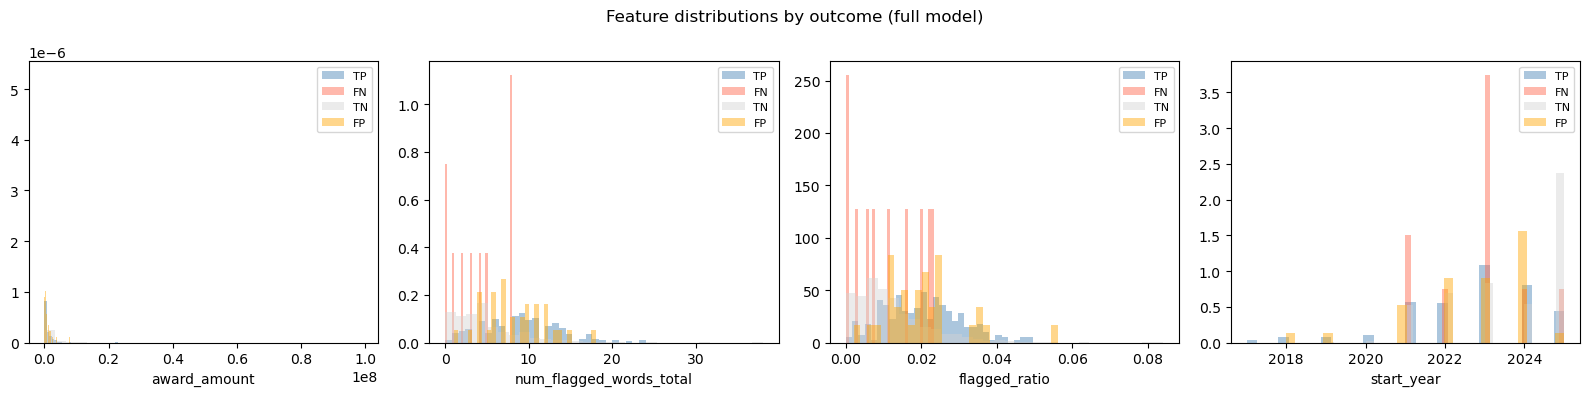

In [85]:
num_cols_plot = [c for c in ['award_amount', 'num_flagged_words_total',
                              'flagged_ratio', 'start_year'] if c in df.columns]
if num_cols_plot:
    fig, axes = plt.subplots(1, len(num_cols_plot), figsize=(4 * len(num_cols_plot), 4))
    if len(num_cols_plot) == 1:
        axes = [axes]
    for ax, col in zip(axes, num_cols_plot):
        for label, grp, color in [
            ('TP', tp, 'steelblue'), ('FN', fn, 'tomato'),
            ('TN', tn, 'lightgray'), ('FP', fp, 'orange')
        ]:
            vals = grp[col].dropna()
            if len(vals) > 0:
                ax.hist(vals, bins=30, alpha=0.45, label=label, color=color, density=True)
        ax.set_xlabel(col)
        ax.legend(fontsize=8)
    plt.suptitle('Feature distributions by outcome (full model)')
    plt.tight_layout()
    plt.show()
